# Building a poker bot with Deep CFR

** · Deep Counterfactual Regret Minimization · Leduc Hold'em**

Run this top to bottom in Colab. No data files, no downloads — everything is
self-contained.

---

## What this notebook does

Tabular CFR keeps a regret number for every decision the bot could ever face.
That works beautifully until the game gets big: full Texas hold'em has about
10¹⁷ decision points, so the table cannot exist.

**Deep CFR** (Brown, Lerer, Gross & Sandholm, 2019) replaces the table with a
neural network that *generalises* across decisions:

$$V(I, a \mid \theta) \;\approx\; R^t(I, a)$$

The network predicts the regret that tabular CFR *would* have stored. Situations
it has never seen get a sensible answer because they look like situations it has.

We build it on **Leduc hold'em**, which is deliberately small (288 information
sets) — small enough that we can compute the *exact* optimal answer and check the
neural bot's homework against it. That check is the whole point: on a big game you
could never tell whether your bot works.

## What you should expect to find

Something slightly surprising, which is the most interesting result here:

> On Leduc, Deep CFR is **worse** than plain tabular CFR — and that is correct
> behaviour, not a bug.

We'll measure it, explain why the theory predicts it, and explain when the neural
version is nonetheless the only option.

In [ ]:
import math, random, time, json
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0); random.seed(0); np.random.seed(0)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


---
# Part 1 · The game

**Leduc hold'em** is the standard small benchmark for imperfect-information
solvers:

* 6-card deck — J, Q, K in two suits
* both players ante 1, then get one private card
* round 1 betting (bet size 2), then **one public card** is dealt, then round 2
  (bet size 4)
* at most 2 raises per round
* a private card that pairs the public card wins; otherwise higher rank wins

Two published numbers we will hold ourselves to: **288 information sets**, and a
game value to player 0 of about **−0.0856**. If our code doesn't reproduce both,
nothing after this point is trustworthy.

In [ ]:
RANKS = "JQK"
BET = (2, 4)          # bet size in round 1, round 2
MAX_RAISES = 2
NUM_CARDS = 6
FOLD, CALL, RAISE = 0, 1, 2
rank = lambda c: c // 2

class LeducState:
    """One node of the Leduc game tree."""
    def __init__(self, hole=None, public=None, rnd=0, seq="", hist="",
                 committed=None, street=None, folder=None):
        self.hole = hole; self.public = public; self.rnd = rnd
        self.seq = seq            # actions this round
        self.hist = hist          # full betting history, rounds joined by "/"
        self.committed = committed if committed is not None else [1, 1]
        self.street = street if street is not None else [0, 0]
        self.folder = folder

    # Structure
    def round_closed(self):
        s = self.seq
        if not s: return False
        if s[-1] == "f": return True
        if s == "cc": return True
        return len(s) >= 2 and s[-1] == "c" and s[-2] == "r"

    def is_terminal(self):
        return self.folder is not None or (self.rnd == 1 and self.round_closed())

    def is_chance(self):
        return self.hole is None or (self.rnd == 1 and self.public is None)

    def current_player(self):
        return len(self.seq) % 2

    def facing_bet(self):
        return bool(self.seq) and self.seq[-1] == "r"

    def legal_actions(self):
        a = []
        if self.facing_bet(): a.append(FOLD)
        a.append(CALL)
        if self.seq.count("r") < MAX_RAISES: a.append(RAISE)
        return a

    def chance_outcomes(self):
        if self.hole is None:
            deals = [(x, y) for x in range(NUM_CARDS) for y in range(NUM_CARDS) if x != y]
            return [(i, 1 / len(deals)) for i in range(len(deals))]
        rest = [c for c in range(NUM_CARDS) if c not in self.hole]
        return [(c, 1 / len(rest)) for c in rest]

    def apply_action(self, a):
        if self.hole is None:
            deals = [(x, y) for x in range(NUM_CARDS) for y in range(NUM_CARDS) if x != y]
            return LeducState(hole=deals[a])
        if self.rnd == 1 and self.public is None:
            return LeducState(self.hole, a, 1, "", self.hist + "/",
                              list(self.committed), [0, 0])
        p = len(self.seq) % 2
        street, committed, folder = list(self.street), list(self.committed), None
        if a == FOLD:    folder = p
        elif a == CALL:  street[p] = max(street)
        else:            street[p] = max(street) + BET[self.rnd]
        ch = "fcr"[a]
        n = LeducState(self.hole, self.public, self.rnd, self.seq + ch,
                       self.hist + ch, committed, street, folder)
        if n.round_closed():
            n.committed = [committed[i] + street[i] for i in range(2)]
            n.street = [0, 0]
            if folder is None and n.rnd == 0:
                n.rnd, n.seq, n.public = 1, "", None
        return n

    # Payoffs
    def returns(self):
        if self.folder is not None:
            amt = float(self.committed[self.folder])
            return [-amt, amt] if self.folder == 0 else [amt, -amt]
        pub = rank(self.public)
        r0, r1 = rank(self.hole[0]), rank(self.hole[1])
        p0, p1 = (r0 == pub), (r1 == pub)          # pairing the board wins
        amt = float(self.committed[0])
        if p0 != p1:  return [amt, -amt] if p0 else [-amt, amt]
        if r0 == r1:  return [0.0, 0.0]
        return [amt, -amt] if r0 > r1 else [-amt, amt]

    # What the acting player can actually see
    def information_state_key(self, player=None):
        p = self.current_player() if player is None else player
        pub = RANKS[rank(self.public)] if self.public is not None else "?"
        return f"{RANKS[rank(self.hole[p])]}{pub}|{self.hist}"

def new_game():
    return LeducState()

print("sample hand:")
s = new_game().apply_action(3)
print("  hole cards:", s.hole, "-> ranks", [RANKS[rank(c)] for c in s.hole])
print("  player 0 sees:", s.information_state_key())
print("  legal actions:", s.legal_actions())

sample hand:
  hole cards: (0, 4) -> ranks ['J', 'K']
  player 0 sees: J?|
  legal actions: [1, 2]


## The evaluator: how do we know the bot is any good?

**Exploitability** is the standard measure. It asks: if an opponent knew our
strategy exactly and played the perfect counter to it, how much would they win?

* exploitability **0** ⇒ nobody can beat us ⇒ **Nash equilibrium**
* higher ⇒ more beatable

Computing it exactly needs care. A best-responding opponent must play the *same*
action at every history inside an information set, because those histories are
indistinguishable to them. So we resolve each information set once, by averaging
over every history in it, weighted by how likely we and chance were to allow it.

We flatten the tree into arrays first — it makes everything below fast enough to
run interactively.

In [ ]:
TERMINAL, CHANCE, PLAYER = 0, 1, 2

class GameTree:
    """Flatten the game into arrays, in DFS pre-order."""
    def __init__(self, root):
        self.kind, self.player, self.infoset = [], [], []
        self.children, self.probs, self.util, self.actions = [], [], [], []
        self.keys, self.n_actions, self.iset_player, self.iset_nodes = [], [], [], []
        self._index = {}
        self._build(root)

    def _new(self):
        self.kind.append(TERMINAL); self.player.append(-2); self.infoset.append(-1)
        self.children.append([]); self.probs.append([]); self.util.append([])
        self.actions.append([])
        return len(self.kind) - 1

    def _iset(self, key, n, player):
        i = self._index.get(key)
        if i is None:
            i = len(self.keys); self._index[key] = i
            self.keys.append(key); self.n_actions.append(n)
            self.iset_player.append(player); self.iset_nodes.append([])
        return i

    def _build(self, s):
        idx = self._new()
        if s.is_terminal():
            self.kind[idx] = TERMINAL; self.util[idx] = s.returns(); return idx
        if s.is_chance():
            out = s.chance_outcomes()
            self.kind[idx] = CHANCE
            self.probs[idx] = [p for _, p in out]
            self.children[idx] = [self._build(s.apply_action(a)) for a, _ in out]
            return idx
        legal, p = s.legal_actions(), s.current_player()
        i = self._iset(s.information_state_key(), len(legal), p)
        self.kind[idx] = PLAYER; self.player[idx] = p; self.infoset[idx] = i
        self.actions[idx] = legal; self.iset_nodes[i].append(idx)
        self.children[idx] = [self._build(s.apply_action(a)) for a in legal]
        return idx

    @property
    def num_infosets(self): return len(self.keys)
    @property
    def num_nodes(self): return len(self.kind)

TREE = GameTree(new_game())
LEGAL_OF = {k: TREE.actions[TREE.iset_nodes[i][0]] for i, k in enumerate(TREE.keys)}
PLAYER_OF = {k: TREE.iset_player[i] for i, k in enumerate(TREE.keys)}

per_player = defaultdict(int)
for p in TREE.iset_player: per_player[p] += 1
print(f"nodes {TREE.num_nodes} | information sets {TREE.num_infosets} "
      f"(player 0: {per_player[0]}, player 1: {per_player[1]})")
assert TREE.num_infosets == 288, "should be 288 -- the published number"
print("matches the published 288")

nodes 9451 | information sets 288 (player 0: 144, player 1: 144)
matches the published 288


In [ ]:
def _policy_at(policy, iset):
    p = policy.get(TREE.keys[iset])
    return p if p is not None else [1 / TREE.n_actions[iset]] * TREE.n_actions[iset]

def expected_value(policy):
    """Expected chips per hand when both players follow `policy`."""
    memo = {}
    def rec(node):
        if node in memo: return memo[node]
        k = TREE.kind[node]
        if k == TERMINAL: out = list(TREE.util[node])
        elif k == CHANCE:
            out = [0.0, 0.0]
            for c, pr in zip(TREE.children[node], TREE.probs[node]):
                s = rec(c); out[0] += pr * s[0]; out[1] += pr * s[1]
        else:
            sg = _policy_at(policy, TREE.infoset[node]); out = [0.0, 0.0]
            for i, c in enumerate(TREE.children[node]):
                if sg[i] <= 0: continue
                s = rec(c); out[0] += sg[i] * s[0]; out[1] += sg[i] * s[1]
        memo[node] = out; return out
    return rec(0)

def best_response_value(policy, player):
    """Most a perfect counter-strategy could win against `policy`."""
    n = TREE.num_nodes
    reach = [0.0] * n; reach[0] = 1.0
    for node in range(n):                      # pre-order => parents come first
        r = reach[node]
        if r == 0.0 or TREE.kind[node] == TERMINAL: continue
        kids = TREE.children[node]
        if TREE.kind[node] == CHANCE:
            for c, pr in zip(kids, TREE.probs[node]): reach[c] += r * pr
        elif TREE.player[node] == player:
            for c in kids: reach[c] += r       # responder's own choice: weight 1
        else:
            sg = _policy_at(policy, TREE.infoset[node])
            for i, c in enumerate(kids):
                if sg[i] > 0: reach[c] += r * sg[i]
    choice, memo = {}, [None] * n
    def value(node):
        if memo[node] is not None: return memo[node]
        k = TREE.kind[node]
        if k == TERMINAL: v = TREE.util[node][player]
        elif k == CHANCE:
            v = sum(pr * value(c) for c, pr in zip(TREE.children[node], TREE.probs[node]))
        else:
            iset = TREE.infoset[node]
            if TREE.player[node] == player:
                if iset not in choice:         # resolve the whole infoset at once
                    acc = [0.0] * TREE.n_actions[iset]
                    for m in TREE.iset_nodes[iset]:
                        if reach[m] == 0.0: continue
                        for i, c in enumerate(TREE.children[m]):
                            acc[i] += reach[m] * value(c)
                    choice[iset] = max(range(len(acc)), key=lambda i: acc[i])
                v = value(TREE.children[node][choice[iset]])
            else:
                sg = _policy_at(policy, iset)
                v = sum(sg[i] * value(c) for i, c in enumerate(TREE.children[node]) if sg[i] > 0)
        memo[node] = v; return v
    return value(0)

def exploitability(policy):
    return (best_response_value(policy, 0) + best_response_value(policy, 1)) / 2

### Sanity-check the evaluator before trusting it

A subtle trap: if the exploitability code is wrong, every result below is
meaningless *and it will still look plausible*. So we test the measuring
instrument itself.

A uniformly random strategy should be very exploitable. And a strategy from a
converged tabular solver should be barely exploitable at all. We'll use tabular
CFR as our ground truth throughout.

In [ ]:
class TabularCFR:
    """Ordinary CFR over the flat tree. Our ground truth and our baseline."""
    def __init__(self, plus=False):
        self.plus = plus            # CFR+ clamps negative regret at zero
        self.iterations = 0
        self.regret = [[0.0] * n for n in TREE.n_actions]
        self.strategy_sum = [[0.0] * n for n in TREE.n_actions]

    def _match(self, iset):
        r = self.regret[iset]; pos = [x if x > 0 else 0.0 for x in r]; s = sum(pos)
        return [x / s for x in pos] if s > 0 else [1 / len(r)] * len(r)

    def train(self, iters):
        for _ in range(iters):
            self.iterations += 1
            w = float(self.iterations) if self.plus else 1.0
            for p in (0, 1): self._walk(0, p, 1.0, 1.0, w)

    def _walk(self, node, player, reach_p, reach_cf, w):
        k = TREE.kind[node]
        if k == TERMINAL: return TREE.util[node][player]
        kids = TREE.children[node]
        if k == CHANCE:
            return sum(pr * self._walk(c, player, reach_p, reach_cf * pr, w)
                       for c, pr in zip(kids, TREE.probs[node]))
        iset = TREE.infoset[node]; sg = self._match(iset)
        if TREE.player[node] == player:
            util = [self._walk(kids[i], player, reach_p * sg[i], reach_cf, w)
                    for i in range(len(kids))]
            node_util = sum(sg[i] * util[i] for i in range(len(kids)))
            r, ss = self.regret[iset], self.strategy_sum[iset]
            for i in range(len(kids)):
                nr = r[i] + reach_cf * (util[i] - node_util)
                r[i] = max(nr, 0.0) if self.plus else nr
                ss[i] += w * reach_p * sg[i]
            return node_util
        return sum(sg[i] * self._walk(kids[i], player, reach_p, reach_cf * sg[i], w)
                   for i in range(len(kids)))

    def average_policy(self):
        out = {}
        for i in range(TREE.num_infosets):
            ss = self.strategy_sum[i]; t = sum(ss)
            out[TREE.keys[i]] = [x / t for x in ss] if t > 0 else [1 / len(ss)] * len(ss)
        return out

uniform = {k: [1 / len(v)] * len(v) for k, v in LEGAL_OF.items()}
print(f"random play        : exploitability {exploitability(uniform):.4f}")

t0 = time.time()
tab = TabularCFR(); tab.train(2000)
TABULAR = tab.average_policy()
print(f"tabular CFR (2000) : exploitability {exploitability(TABULAR):.4f}  "
      f"value {expected_value(TABULAR)[0]:+.4f}   ({time.time()-t0:.0f}s)")
print(f"published game value: -0.0856")

random play        : exploitability 2.3736
tabular CFR (2000) : exploitability 0.0134  value -0.0873   (56s)
published game value: -0.0856


The evaluator behaves: random play is wildly exploitable, and CFR drives
exploitability down two orders of magnitude while landing on the published game
value. **Now** we can trust it to judge the neural bot.

---
# Part 2 · Deep CFR

Three pieces are needed to swap the table for a network.

## 2.1 · Features — how the network "sees" a poker situation

A network cannot consume the string `"KQ|cr/rc"`. We hand-encode each information
set as 37 numbers. This encoding is where *all* the generalisation comes from: two
situations that should be played alike must end up near each other in feature
space, or the network learns nothing useful.

We include the private card, the public card, the betting round, whether we pair
the board, a slot-by-slot encoding of the betting so far, raises this round,
whether we face a bet, and the pot size.

In [ ]:
class Featurizer:
    SIZE = 37
    ACTS = "fcr"
    MAX_SLOTS = 3

    def __call__(self, key):
        x = np.zeros(self.SIZE, dtype=np.float32)
        cards, hist = key.split("|")
        priv, pub = cards[0], cards[1]
        x[RANKS.index(priv)] = 1.0                       # 0..2  private card
        if pub != "?":
            x[3 + RANKS.index(pub)] = 1.0                # 3..5  public card
            if pub == priv: x[8] = 1.0                   # 8     we paired the board
        else:
            x[6] = 1.0                                   # 6     no public card yet
        rounds = hist.split("/")
        x[7] = 1.0 if len(rounds) > 1 else 0.0           # 7     betting round
        pot = 2.0
        for r, seq in enumerate(rounds[:2]):             # 9..32 betting history
            bet = BET[r]
            for i, ch in enumerate(seq[:self.MAX_SLOTS]):
                x[9 + r * 12 + i * 4 + 1 + self.ACTS.index(ch)] = 1.0
                if ch in "cr": pot += bet
            for i in range(len(seq), self.MAX_SLOTS):
                x[9 + r * 12 + i * 4] = 1.0              # "nothing happened here"
        cur = rounds[-1]
        x[33] = cur.count("r") / 2.0
        x[34] = 1.0 if (cur and cur[-1] == "r") else 0.0
        x[35] = pot / 20.0
        x[36] = 1.0                                      # bias
        return x

    def batch(self, keys):
        return np.stack([self(k) for k in keys])

FEAT = Featurizer()

# Critical check: if two different situations get the same features, the network
# can never tell them apart and performance is capped no matter how long we train.
X = FEAT.batch(TREE.keys)
distinct = len(set(map(tuple, X.tolist())))
print(f"{X.shape[0]} information sets -> {distinct} distinct feature vectors")
assert distinct == TREE.num_infosets, "feature collision!"
print("no collisions")

288 information sets -> 288 distinct feature vectors
no collisions


## 2.2 · The network and the memory

The network is a small MLP: 37 inputs → 3 hidden layers of 64 → one value per
action.

The **reservoir memory** matters more than it looks. It keeps a uniform random
sample of *everything ever inserted*, even after it fills up. The paper shows that
if you use a sliding window instead, exploitability starts **rising** once the
buffer fills — the memory forgets the early iterations that the running average
still depends on.

In [ ]:
class ValueNet(nn.Module):
    def __init__(self, in_dim, n_actions, hidden=64, depth=3):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.ReLU()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        self.trunk = nn.Sequential(*layers)
        self.norm = nn.LayerNorm(hidden)
        self.head = nn.Linear(hidden, n_actions)

    def forward(self, x):
        return self.head(self.norm(self.trunk(x)))


class ReservoirMemory:
    """Uniform sample of all insertions, at fixed capacity (Vitter 1985)."""
    def __init__(self, capacity, seed=0):
        self.capacity = capacity; self.data = []; self.seen = 0
        self.rng = random.Random(seed)

    def add(self, item):
        self.seen += 1
        if len(self.data) < self.capacity:
            self.data.append(item)
        else:
            j = self.rng.randint(0, self.seen - 1)
            if j < self.capacity: self.data[j] = item

    def __len__(self): return len(self.data)


def regret_match(adv, mask):
    """Strategy from predicted regrets: play in proportion to POSITIVE regret.

    Note the direction -- regret here is regret for NOT having taken an action,
    so a high regret means you wish you had done it, so you do it more often.

    When every regret is negative the paper does not fall back to uniform; it
    puts all probability on the highest-regret action, which copes better with
    approximation error (their Figure 4: uniform is ~50% more exploitable).
    """
    a = np.where(mask, adv, -np.inf)
    pos = np.where(mask, np.maximum(a, 0.0), 0.0)
    tot = pos.sum()
    if tot > 0: return pos / tot
    out = np.zeros_like(pos)
    legal = np.where(mask)[0]
    out[legal[int(np.argmax(a[legal]))]] = 1.0
    return out

## 2.3 · The algorithm

Each Deep CFR iteration does three things:

1. **Traverse.** Run K partial playthroughs using *external sampling*: at the
   traverser's own nodes explore **every** action; at chance and opponent nodes
   sample just one. This is what makes the collected regrets an unbiased estimate
   of the true advantage (Lemma 1 in the paper).
2. **Retrain from scratch.** Rebuild the value network with fresh random weights
   and fit it to the whole memory. Fine-tuning instead of retraining ends up about
   50% more exploitable — a single network gets stuck in bad local minima as the
   objective shifts under it.
3. **Record the average.** Store the strategy played at opponent nodes. It is the
   *average* strategy over all iterations that converges to Nash, not the latest
   one, so a second network is fitted to that average at the end. **That network
   is the bot you actually play.**

Samples are weighted by iteration number `t` (Linear CFR), because the faster CFR
variants like CFR+ handle approximation error poorly.

In [ ]:
class DeepCFR:
    def __init__(self, n_actions=3, hidden=64, depth=3, traversals=1000,
                 sgd_steps=400, batch_size=2048, memory_size=300_000,
                 lr=1e-3, seed=0):
        self.n_actions = n_actions; self.hidden = hidden; self.depth = depth
        self.traversals = traversals; self.sgd_steps = sgd_steps
        self.batch_size = batch_size; self.lr = lr
        self.rng = random.Random(seed)
        self.adv_memory = [ReservoirMemory(memory_size, seed + 1),
                           ReservoirMemory(memory_size, seed + 2)]
        self.strategy_memory = ReservoirMemory(memory_size, seed + 3)
        self.value_nets = [self._net(), self._net()]
        self.policy_net = None
        self.iteration = 0
        self.history = []

    def _net(self):
        return ValueNet(FEAT.SIZE, self.n_actions, self.hidden, self.depth).to(DEVICE)

    def _sample(self, probs):
        r = self.rng.random() * max(sum(probs), 1e-12); acc = 0.0
        for i, p in enumerate(probs):
            acc += p
            if r < acc: return i
        return len(probs) - 1

    @torch.no_grad()
    def _advantages(self, key, player):
        x = torch.from_numpy(FEAT(key)).unsqueeze(0).to(DEVICE)
        return self.value_nets[player](x).cpu().numpy()[0]

    def _strategy(self, key, player, legal):
        mask = np.zeros(self.n_actions, dtype=bool); mask[list(legal)] = True
        return regret_match(self._advantages(key, player), mask)

    # Algorithm 2: traversal with external sampling
    def traverse(self, state, player):
        if state.is_terminal():
            return float(state.returns()[player])
        if state.is_chance():
            out = state.chance_outcomes()
            i = self._sample([p for _, p in out])
            return self.traverse(state.apply_action(out[i][0]), player)

        legal = state.legal_actions()
        key = state.information_state_key()
        cur = state.current_player()
        sigma = self._strategy(key, cur, legal)
        mask = np.array([a in legal for a in range(self.n_actions)])

        if cur == player:
            values = np.zeros(self.n_actions, dtype=np.float32); node_v = 0.0
            for a in legal:                      # explore ALL traverser actions
                v = self.traverse(state.apply_action(a), player)
                values[a] = v; node_v += sigma[a] * v
            regrets = np.zeros(self.n_actions, dtype=np.float32)
            for a in legal: regrets[a] = values[a] - node_v
            self.adv_memory[player].add((key, self.iteration, regrets, mask))
            return node_v

        # opponent node: remember what we played, then sample one action
        self.strategy_memory.add((key, self.iteration, sigma.astype(np.float32), mask))
        i = self._sample([sigma[a] for a in legal])
        return self.traverse(state.apply_action(legal[i]), player)

    #  fitting
    def _fit(self, net, memory, steps):
        data = memory.data
        if not data: return 0.0
        X = torch.from_numpy(FEAT.batch([d[0] for d in data])).to(DEVICE)
        Y = torch.from_numpy(np.stack([d[2] for d in data])).to(DEVICE)
        M = torch.from_numpy(np.stack([d[3] for d in data])).to(DEVICE).float()
        W = torch.tensor([d[1] for d in data], dtype=torch.float32,
                         device=DEVICE) * (2.0 / max(self.iteration, 1))
        opt = torch.optim.Adam(net.parameters(), lr=self.lr)
        n, last = len(data), 0.0
        for _ in range(steps):
            idx = torch.randint(0, n, (min(self.batch_size, n),), device=DEVICE)
            err = ((net(X[idx]) - Y[idx]) ** 2) * M[idx]
            loss = (err.sum(dim=1) * W[idx]).mean()
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), 1.0)
            opt.step(); last = float(loss.item())
        return last

    def train_iteration(self):
        self.iteration += 1
        loss = 0.0
        for player in (0, 1):
            for _ in range(self.traversals):
                self.traverse(new_game(), player)
            self.value_nets[player] = self._net()          # from scratch!
            loss = self._fit(self.value_nets[player], self.adv_memory[player],
                             self.sgd_steps)
        info = {"iteration": self.iteration, "loss": loss,
                "memory": len(self.adv_memory[0])}
        self.history.append(info)
        return info

    def fit_policy(self, steps=1500):
        self.policy_net = self._net()
        return self._fit(self.policy_net, self.strategy_memory, steps)

    def policy(self):
        """The average strategy -- this is the bot."""
        if self.policy_net is None: self.fit_policy()
        X = torch.from_numpy(FEAT.batch(TREE.keys)).to(DEVICE)
        with torch.no_grad():
            logits = self.policy_net(X).cpu().numpy()
        out = {}
        for i, k in enumerate(TREE.keys):
            legal = LEGAL_OF[k]
            v = np.maximum(logits[i][legal], 0.0); s = v.sum()
            out[k] = (v / s).tolist() if s > 0 else [1 / len(legal)] * len(legal)
        return out

print("Deep CFR ready")

Deep CFR ready


---
# Part 3 · Train it

Each iteration runs 2 × 1000 traversals and retrains both networks from scratch,
so this is not instant. **About 15 iterations takes ~4 minutes on a Colab CPU** and
is enough to see exploitability fall sharply from its starting point.

Set `ITERATIONS` higher if you want to watch it approach the plateau (we used 89
for the shipped bot). A GPU helps only a little — most of the time goes on the
Python game traversals, not the matrix multiplies.

In [ ]:
ITERATIONS = 15          # raise to 50-90 to reach the plateau
EVAL_EVERY = 5

deep = DeepCFR(traversals=1000, sgd_steps=400, seed=0)
curve = []
t0 = time.time()
for it in range(1, ITERATIONS + 1):
    info = deep.train_iteration()
    if it % EVAL_EVERY == 0 or it == 1:
        deep.fit_policy(1500)
        pol = deep.policy()
        e, v = exploitability(pol), expected_value(pol)[0]
        curve.append((it, e, v))
        print(f"iter {it:3d} | loss {info['loss']:7.2f} | memory {info['memory']:6d} "
              f"| exploitability {e:.4f} | value {v:+.4f} | {time.time()-t0:.0f}s")
print(f"\ndone in {time.time()-t0:.0f}s")

iter   1 | loss   60.55 | memory   3863 | exploitability 3.1216 | value +1.0001 | 29s
iter   5 | loss   56.97 | memory  28615 | exploitability 1.6718 | value -0.1761 | 95s
iter  10 | loss   38.24 | memory  60070 | exploitability 0.9290 | value -0.0748 | 170s
iter  15 | loss   30.19 | memory  88212 | exploitability 0.4617 | value -0.0946 | 245s

done in 245s


### A diagnostic worth doing: is that huge loss a problem?

The training loss sits around 40–50, which looks alarming. Before trying to fix
it, work out what the *best possible* loss would be.

The network's target is a single noisy sample of regret from one traversal. The
best any model can do is predict the **average** regret for that information set —
it can never predict the noise. So the irreducible loss is the variance of the
targets around their per-information-set mean.

In [ ]:
data = deep.adv_memory[0].data
acc = defaultdict(list)
for k, t, r, m in data: acc[k].append((t, r, m))

sse, n = 0.0, 0
for k, items in acc.items():
    W = np.array([t for t, _, _ in items], float)
    R = np.stack([r for _, r, _ in items]); M = np.stack([m for _, _, m in items]).astype(float)
    mu = (R * W[:, None]).sum(0) / W.sum()          # best possible prediction
    sse += (((R - mu) ** 2 * M).sum(1) * W * (2.0 / deep.iteration)).sum()
    n += len(items)
print(f"irreducible loss (a perfect model)   : {sse / n:.2f}")
print(f"loss our network actually achieved   : {deep.history[-1]['loss']:.2f}")

net = deep.value_nets[0]
ks = list(acc.keys())
with torch.no_grad():
    P = net(torch.from_numpy(FEAT.batch(ks)).to(DEVICE)).cpu().numpy()
errs = []
for i, k in enumerate(ks):
    items = acc[k]; W = np.array([t for t, _, _ in items], float)
    R = np.stack([r for _, r, _ in items]); m = items[0][2]
    mu = (R * W[:, None]).sum(0) / W.sum()
    errs.append(np.abs(P[i] - mu)[m].mean())
print(f"\nmean |prediction - true average|     : {np.mean(errs):.3f}")
print(f"typical size of a regret target      : {np.abs(np.stack([d[2] for d in data])).mean():.3f}")
print("\n=> the loss is almost entirely sampling noise; the network fits well.")

irreducible loss (a perfect model)   : 33.83
loss our network actually achieved   : 30.19

mean |prediction - true average|     : 0.360
typical size of a regret target      : 2.096

=> the loss is almost entirely sampling noise; the network fits well.


That's the answer: the loss is dominated by irreducible noise, and the network
predicts the true conditional mean closely. **The lesson is practical** — if you
try to fix this "high loss" with more SGD steps you will waste your entire compute
budget. More *traversals* (less noise) is what actually helps.

---
# Part 4 · Comparison

Now the result the whole notebook was built to measure.

In [ ]:
# Load our 89-iteration run so the comparison doesn't depend on a short demo run.
PRETRAINED = json.loads(r"""{"J?|":[0.774,0.226],"J?|c":[0.756,0.243],"JQ|cc/":[1.0,0.0],"JQ|cc/c":[0.922,0.078],"JQ|cc/cr":[0.982,0.004,0.015],"JQ|cc/crr":[0.965,0.035],"JQ|cc/r":[0.983,0.017,0.0],"JQ|cc/rr":[1.0,0.0],"JK|cc/":[0.84,0.16],"JK|cc/c":[0.988,0.012],"JK|cc/cr":[0.944,0.023,0.033],"JK|cc/crr":[0.871,0.129],"JK|cc/r":[0.971,0.0,0.029],"JK|cc/rr":[1.0,0.0],"J?|cr":[0.712,0.253,0.035],"JQ|crc/":[0.594,0.406],"JQ|crc/c":[0.667,0.333],"JQ|crc/cr":[0.913,0.006,0.081],"JQ|crc/crr":[0.897,0.102],"JQ|crc/r":[0.898,0.01,0.092],"JQ|crc/rr":[1.0,0.0],"JK|crc/":[0.887,0.113],"JK|crc/c":[0.306,0.694],"JK|crc/cr":[0.942,0.016,0.042],"JK|crc/crr":[0.732,0.268],"JK|crc/r":[0.894,0.0,0.106],"JK|crc/rr":[0.986,0.014],"J?|crr":[0.0,1.0],"JQ|crrc/":[0.709,0.291],"JQ|crrc/c":[0.819,0.181],"JQ|crrc/cr":[0.924,0.0,0.076],"JQ|crrc/crr":[0.892,0.108],"JQ|crrc/r":[0.902,0.017,0.081],"JQ|crrc/rr":[1.0,0.0],"JK|crrc/":[0.389,0.611],"JK|crrc/c":[0.448,0.552],"JK|crrc/cr":[1.0,0.0,0.0],"JK|crrc/crr":[0.96,0.04],"JK|crrc/r":[0.913,0.012,0.075],"JK|crrc/rr":[0.985,0.015],"J?|r":[0.619,0.309,0.072],"JQ|rc/":[0.768,0.232],"JQ|rc/c":[0.459,0.541],"JQ|rc/cr":[0.938,0.005,0.058],"JQ|rc/crr":[1.0,0.0],"JQ|rc/r":[0.936,0.0,0.064],"JQ|rc/rr":[1.0,0.0],"JK|rc/":[0.546,0.454],"JK|rc/c":[0.81,0.19],"JK|rc/cr":[0.983,0.01,0.007],"JK|rc/crr":[0.974,0.026],"JK|rc/r":[0.922,0.011,0.067],"JK|rc/rr":[0.988,0.012],"J?|rr":[0.0,1.0],"JQ|rrc/":[0.833,0.167],"JQ|rrc/c":[0.815,0.185],"JQ|rrc/cr":[0.944,0.022,0.034],"JQ|rrc/crr":[0.813,0.187],"JQ|rrc/r":[0.769,0.035,0.196],"JQ|rrc/rr":[0.988,0.012],"JK|rrc/":[0.689,0.311],"JK|rrc/c":[0.096,0.904],"JK|rrc/cr":[0.827,0.011,0.162],"JK|rrc/crr":[0.968,0.033],"JK|rrc/r":[0.891,0.0,0.109],"JK|rrc/rr":[0.973,0.027],"Q?|c":[0.403,0.597],"JJ|cc/":[0.876,0.124],"QJ|cc/c":[0.942,0.058],"JJ|cc/cr":[0.0,0.42,0.58],"QJ|cc/crr":[0.864,0.136],"QJ|cc/r":[0.989,0.0,0.011],"JJ|cc/rr":[0.0,1.0],"QQ|cc/c":[0.119,0.881],"QQ|cc/crr":[0.017,0.983],"QQ|cc/r":[0.039,0.561,0.4],"QK|cc/c":[0.822,0.178],"QK|cc/crr":[0.308,0.692],"QK|cc/r":[0.365,0.62,0.015],"JJ|crc/":[0.067,0.933],"QJ|crc/c":[0.782,0.218],"JJ|crc/cr":[0.072,0.137,0.791],"QJ|crc/crr":[0.703,0.297],"QJ|crc/r":[0.935,0.031,0.034],"JJ|crc/rr":[0.0,1.0],"QQ|crc/c":[0.022,0.978],"QQ|crc/crr":[0.003,0.997],"QQ|crc/r":[0.008,0.358,0.634],"QK|crc/c":[0.617,0.383],"QK|crc/crr":[0.338,0.662],"QK|crc/r":[0.449,0.516,0.035],"Q?|crr":[0.009,0.991],"JJ|crrc/":[0.284,0.716],"QJ|crrc/c":[0.966,0.035],"JJ|crrc/cr":[0.0,0.052,0.948],"QJ|crrc/crr":[0.419,0.581],"QJ|crrc/r":[0.971,0.017,0.012],"JJ|crrc/rr":[0.004,0.996],"QQ|crrc/c":[0.0,1.0],"QQ|crrc/crr":[0.0,1.0],"QQ|crrc/r":[0.042,0.0,0.958],"QK|crrc/c":[0.791,0.209],"QK|crrc/crr":[0.373,0.627],"QK|crrc/r":[0.524,0.442,0.034],"Q?|r":[0.092,0.52,0.387],"JJ|rc/":[0.262,0.738],"QJ|rc/c":[0.857,0.143],"JJ|rc/cr":[0.0,0.0,1.0],"QJ|rc/crr":[0.87,0.131],"QJ|rc/r":[0.886,0.01,0.103],"JJ|rc/rr":[0.0,1.0],"QQ|rc/c":[0.0,1.0],"QQ|rc/crr":[0.008,0.992],"QQ|rc/r":[0.025,0.0,0.974],"QK|rc/c":[0.628,0.372],"QK|rc/crr":[0.267,0.733],"QK|rc/r":[0.244,0.714,0.042],"JJ|rrc/":[0.087,0.912],"QJ|rrc/c":[0.956,0.044],"JJ|rrc/cr":[0.076,0.0,0.924],"QJ|rrc/crr":[0.829,0.171],"QJ|rrc/r":[0.96,0.019,0.021],"JJ|rrc/rr":[0.0,1.0],"QQ|rrc/c":[0.019,0.981],"QQ|rrc/crr":[0.003,0.997],"QQ|rrc/r":[0.0,0.0,1.0],"QK|rrc/c":[0.224,0.776],"QK|rrc/crr":[0.938,0.062],"QK|rrc/r":[0.541,0.407,0.051],"K?|c":[0.11,0.89],"KJ|cc/c":[0.94,0.06],"KJ|cc/crr":[0.694,0.306],"KJ|cc/r":[0.989,0.0,0.011],"KQ|cc/c":[0.975,0.025],"KQ|cc/crr":[0.522,0.478],"KQ|cc/r":[0.944,0.032,0.024],"KK|cc/c":[0.008,0.992],"KK|cc/crr":[0.0,1.0],"KK|cc/r":[0.011,0.0,0.989],"KJ|crc/c":[0.764,0.235],"KJ|crc/crr":[0.026,0.974],"KJ|crc/r":[0.335,0.657,0.008],"KQ|crc/c":[0.923,0.077],"KQ|crc/crr":[0.729,0.271],"KQ|crc/r":[0.412,0.557,0.031],"KK|crc/c":[0.016,0.984],"KK|crc/crr":[0.0,1.0],"KK|crc/r":[0.0,0.202,0.798],"K?|crr":[0.0,1.0],"KJ|crrc/c":[0.715,0.285],"KJ|crrc/crr":[0.197,0.803],"KJ|crrc/r":[0.023,0.9,0.077],"KQ|crrc/c":[0.514,0.486],"KQ|crrc/crr":[0.123,0.876],"KQ|crrc/r":[0.102,0.771,0.127],"KK|crrc/c":[0.013,0.987],"KK|crrc/crr":[0.0,1.0],"KK|crrc/r":[0.0,0.003,0.997],"K?|r":[0.0,0.26,0.74],"KJ|rc/c":[0.506,0.494],"KJ|rc/crr":[0.424,0.576],"KJ|rc/r":[0.085,0.806,0.11],"KQ|rc/c":[0.81,0.19],"KQ|rc/crr":[0.902,0.098],"KQ|rc/r":[0.478,0.449,0.073],"KK|rc/c":[0.005,0.995],"KK|rc/crr":[0.0,1.0],"KK|rc/r":[0.0,0.0,1.0],"KJ|rrc/c":[0.606,0.394],"KJ|rrc/crr":[0.0,1.0],"KJ|rrc/r":[0.027,0.935,0.039],"KQ|rrc/c":[0.783,0.216],"KQ|rrc/crr":[0.395,0.605],"KQ|rrc/r":[0.157,0.692,0.151],"KK|rrc/c":[0.0,1.0],"KK|rrc/crr":[0.0,1.0],"KK|rrc/r":[0.0,0.028,0.972],"Q?|":[0.337,0.663],"QJ|cc/":[0.993,0.007],"JJ|cc/c":[0.301,0.699],"QJ|cc/cr":[0.941,0.033,0.026],"JJ|cc/crr":[0.0,1.0],"JJ|cc/r":[0.0,0.594,0.406],"QJ|cc/rr":[0.935,0.065],"QQ|cc/":[0.927,0.073],"QQ|cc/cr":[0.003,0.554,0.443],"QQ|cc/rr":[0.0,1.0],"QK|cc/":[0.851,0.149],"QK|cc/cr":[0.053,0.879,0.068],"QK|cc/rr":[0.331,0.669],"Q?|cr":[0.246,0.682,0.072],"QJ|crc/":[0.756,0.244],"JJ|crc/c":[0.033,0.967],"QJ|crc/cr":[0.949,0.037,0.015],"JJ|crc/crr":[0.0,1.0],"JJ|crc/r":[0.0,0.087,0.913],"QJ|crc/rr":[0.934,0.066],"QQ|crc/":[0.104,0.896],"QQ|crc/cr":[0.01,0.112,0.878],"QQ|crc/rr":[0.0,1.0],"QK|crc/":[0.98,0.021],"QK|crc/cr":[0.558,0.417,0.025],"QK|crc/rr":[0.496,0.504],"QJ|crrc/":[0.93,0.07],"JJ|crrc/c":[0.053,0.947],"QJ|crrc/cr":[0.887,0.105,0.007],"JJ|crrc/crr":[0.0,1.0],"JJ|crrc/r":[0.0,0.081,0.919],"QJ|crrc/rr":[0.869,0.132],"QQ|crrc/":[0.127,0.873],"QQ|crrc/cr":[0.0,0.0,1.0],"QQ|crrc/rr":[0.0,1.0],"QK|crrc/":[0.789,0.211],"QK|crrc/cr":[0.468,0.532,0.0],"QK|crrc/rr":[0.556,0.444],"QJ|rc/":[0.714,0.286],"JJ|rc/c":[0.026,0.974],"QJ|rc/cr":[0.926,0.017,0.057],"JJ|rc/crr":[0.0,1.0],"JJ|rc/r":[0.0,0.029,0.971],"QJ|rc/rr":[1.0,0.0],"QQ|rc/":[0.538,0.462],"QQ|rc/cr":[0.011,0.0,0.989],"QQ|rc/rr":[0.005,0.995],"QK|rc/":[0.443,0.557],"QK|rc/cr":[0.311,0.609,0.08],"QK|rc/rr":[0.252,0.748],"Q?|rr":[0.006,0.994],"QJ|rrc/":[0.959,0.041],"JJ|rrc/c":[0.0,1.0],"QJ|rrc/cr":[0.944,0.024,0.032],"JJ|rrc/crr":[0.0,1.0],"JJ|rrc/r":[0.0,0.029,0.971],"QJ|rrc/rr":[1.0,0.0],"QQ|rrc/":[0.045,0.955],"QQ|rrc/cr":[0.0,0.0,1.0],"QQ|rrc/rr":[0.005,0.995],"QK|rrc/":[0.843,0.157],"QK|rrc/cr":[0.646,0.314,0.04],"QK|rrc/rr":[0.968,0.032],"K?|":[0.153,0.847],"KJ|cc/":[0.986,0.014],"KJ|cc/cr":[0.944,0.048,0.008],"KJ|cc/rr":[0.715,0.285],"KQ|cc/":[1.0,0.0],"KQ|cc/cr":[0.443,0.524,0.033],"KQ|cc/rr":[0.836,0.164],"KK|cc/":[0.109,0.891],"KK|cc/cr":[0.0,0.088,0.912],"KK|cc/rr":[0.005,0.995],"K?|cr":[0.0,0.171,0.829],"KJ|crc/":[0.921,0.079],"KJ|crc/cr":[0.025,0.88,0.095],"KJ|crc/rr":[0.119,0.881],"KQ|crc/":[0.819,0.181],"KQ|crc/cr":[0.333,0.667,0.0],"KQ|crc/rr":[0.535,0.465],"KK|crc/":[0.541,0.459],"KK|crc/cr":[0.042,0.069,0.889],"KK|crc/rr":[0.008,0.992],"KJ|crrc/":[0.919,0.081],"KJ|crrc/cr":[0.0,0.973,0.027],"KJ|crrc/rr":[0.032,0.968],"KQ|crrc/":[0.854,0.146],"KQ|crrc/cr":[0.328,0.643,0.029],"KQ|crrc/rr":[0.31,0.69],"KK|crrc/":[0.058,0.942],"KK|crrc/cr":[0.079,0.0,0.921],"KK|crrc/rr":[0.0,1.0],"KJ|rc/":[0.906,0.094],"KJ|rc/cr":[0.318,0.621,0.06],"KJ|rc/rr":[0.322,0.678],"KQ|rc/":[0.919,0.081],"KQ|rc/cr":[0.377,0.612,0.011],"KQ|rc/rr":[0.858,0.142],"KK|rc/":[0.022,0.978],"KK|rc/cr":[0.024,0.0,0.977],"KK|rc/rr":[0.0,1.0],"K?|rr":[0.0,1.0],"KJ|rrc/":[0.6,0.4],"KJ|rrc/cr":[0.0,0.861,0.139],"KJ|rrc/rr":[0.05,0.95],"KQ|rrc/":[0.634,0.366],"KQ|rrc/cr":[0.071,0.925,0.004],"KQ|rrc/rr":[0.363,0.637],"KK|rrc/":[0.327,0.673],"KK|rrc/cr":[0.0,0.0,1.0],"KK|rrc/rr":[0.0,1.0]}""")
HISTORY = json.loads(r"""[{"iteration":5,"exploitability":1.4316,"value":0.0609},{"iteration":10,"exploitability":0.5553,"value":-0.0894},{"iteration":15,"exploitability":0.5078,"value":-0.1427},{"iteration":20,"exploitability":0.5245,"value":-0.0757},{"iteration":25,"exploitability":0.3351,"value":-0.0453},{"iteration":30,"exploitability":0.253,"value":-0.0249},{"iteration":35,"exploitability":0.2859,"value":-0.0628},{"iteration":40,"exploitability":0.2097,"value":-0.0639},{"iteration":45,"exploitability":0.2117,"value":-0.0792},{"iteration":50,"exploitability":0.1942,"value":-0.0755},{"iteration":55,"exploitability":0.187,"value":-0.077},{"iteration":60,"exploitability":0.2628,"value":-0.1061},{"iteration":65,"exploitability":0.2519,"value":-0.1011},{"iteration":70,"exploitability":0.2402,"value":-0.1232},{"iteration":75,"exploitability":0.2023,"value":-0.1222},{"iteration":80,"exploitability":0.2664,"value":-0.1067},{"iteration":85,"exploitability":0.2322,"value":-0.1085}]""")

deep_pol = PRETRAINED
print(f"Deep CFR (89 iterations)   exploitability {exploitability(deep_pol):.4f} "
      f"value {expected_value(deep_pol)[0]:+.4f}")

for T in (89, 500, 2000):
    t = TabularCFR(); t.train(T); p = t.average_policy()
    print(f"tabular CFR (T={T:5d})     exploitability {exploitability(p):.4f} "
          f"value {expected_value(p)[0]:+.4f}")
print(f"random play                exploitability {exploitability(uniform):.4f}")

Deep CFR (89 iterations)   exploitability 0.2415 value -0.1121
tabular CFR (T=   89)     exploitability 0.0929 value -0.1196
tabular CFR (T=  500)     exploitability 0.0265 value -0.0916
tabular CFR (T= 2000)     exploitability 0.0134 value -0.0873
random play                exploitability 2.3736


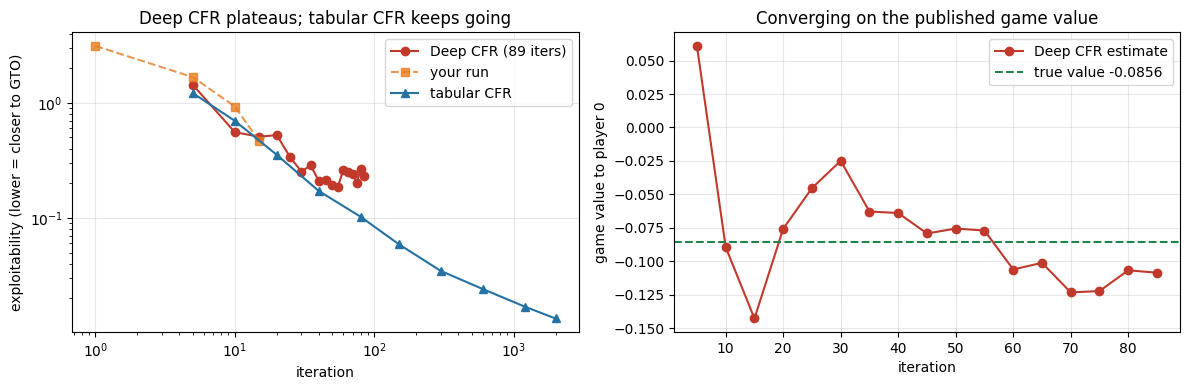

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

it = [h["iteration"] for h in HISTORY]; ex = [h["exploitability"] for h in HISTORY]
ax[0].plot(it, ex, "o-", color="#C0392B", label="Deep CFR (89 iters)")
if curve:
    ax[0].plot([c[0] for c in curve], [c[1] for c in curve], "s--",
               color="#E67E22", alpha=.8, label="your run")
tab_curve = []
t = TabularCFR()
for T in (5, 10, 20, 40, 80, 150, 300, 600, 1200, 2000):
    t.train(T - t.iterations); tab_curve.append((T, exploitability(t.average_policy())))
ax[0].plot([c[0] for c in tab_curve], [c[1] for c in tab_curve], "^-",
           color="#2471A3", label="tabular CFR")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("iteration"); ax[0].set_ylabel("exploitability (lower = closer to GTO)")
ax[0].set_title("Deep CFR plateaus; tabular CFR keeps going")
ax[0].legend(); ax[0].grid(alpha=.3)

vals = [h["value"] for h in HISTORY]
ax[1].plot(it, vals, "o-", color="#C0392B", label="Deep CFR estimate")
ax[1].axhline(-0.0856, color="#1E8449", ls="--", label="true value -0.0856")
ax[1].set_xlabel("iteration"); ax[1].set_ylabel("game value to player 0")
ax[1].set_title("Converging on the published game value")
ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## Why Deep CFR loses here — and why that's the right answer

Tabular CFR reaches ~0.013 exploitability. Deep CFR flattens out around **0.20 and
stops improving**. That is not a bug, and it is not fixed by training longer.

The paper's **Corollary 1** says average regret is bounded by

$$4|\mathcal{I}_p|\sqrt{|A| \Delta \epsilon_{\mathcal{L}}}$$

where $\epsilon_{\mathcal{L}}$ is how badly the network fits the regrets. Tabular
CFR has $\epsilon_{\mathcal{L}} = 0$ — a table can represent any regret exactly —
so it converges toward zero. A neural network never fits perfectly, so Deep CFR
converges to a **floor set by its approximation error**, not to zero.

On Leduc that trade is a pure loss: 288 information sets fit in a table
comfortably, so approximating them can only throw information away.

**So when is Deep CFR the right tool?** When the table cannot exist:

| | information sets | table? |
|---|---|---|
| Leduc (here) | 288 | trivial — use tabular |
| Flop hold'em (the paper) | ~10⁹ | impossible |
| Full no-limit hold'em | ~10¹⁷ | impossible |

The classical alternative is *abstraction* — hand-bucketing similar situations
until the table fits — which needs domain expertise and throws away strategic
detail. Deep CFR's real claim is that it matches a 3.6-million-cluster expert
abstraction on flop hold'em **without anyone hand-designing the buckets**, since
the network learns which situations resemble each other.

The right summary for a report: *Deep CFR trades exact convergence for the ability
to run at all.*

---
# Part 5 · Play the bot

In [ ]:
def bot_action(state, policy, rng=random):
    key = state.information_state_key()
    legal = state.legal_actions()
    probs = policy.get(key, [1 / len(legal)] * len(legal))
    if len(probs) != len(legal): probs = [1 / len(legal)] * len(legal)
    r, acc = rng.random() * sum(probs), 0.0
    for i, p in enumerate(probs):
        acc += p
        if r < acc: return legal[i], probs
    return legal[-1], probs

def play_hand(policy, human_seat=0, verbose=True, rng=random, human_fn=None):
    s = new_game()
    s = s.apply_action(rng.randrange(len(s.chance_outcomes())))     # deal
    if verbose:
        print(f"your card: {RANKS[rank(s.hole[human_seat])]}")
    while not s.is_terminal():
        if s.is_chance():
            rest = [c for c, _ in s.chance_outcomes()]
            s = s.apply_action(rng.choice(rest))
            if verbose: print(f"public card: {RANKS[rank(s.public)]}  (pot {sum(s.committed)})")
            continue
        legal = s.legal_actions()
        names = {0: "fold", 1: "call/check", 2: "raise"}
        if s.current_player() == human_seat:
            if human_fn is None:
                a = 1 if 1 in legal else legal[0]
            else:
                a = human_fn(s, legal)
            if verbose: print(f"  you: {names[a]}")
        else:
            a, probs = bot_action(s, policy, rng)
            if verbose:
                mix = ", ".join(f"{names[legal[i]]} {probs[i]*100:.0f}%" for i in range(len(legal)))
                print(f"  bot: {names[a]}   (its mix: {mix})")
        s = s.apply_action(a)
    r = s.returns()[human_seat]
    if verbose:
        if s.folder is None:
            print(f"  showdown: bot had {RANKS[rank(s.hole[1-human_seat])]}")
        print(f"  result: {r:+.0f} chips\n")
    return r

random.seed(7)
for _ in range(3):
    play_hand(deep_pol)

your card: Q
  you: call/check
  bot: raise   (its mix: call/check 76%, raise 24%)
  you: call/check
public card: K  (pot 6)
  you: call/check
  bot: raise   (its mix: call/check 31%, raise 69%)
  you: call/check
  showdown: bot had J
  result: +7 chips

your card: J
  you: call/check
  bot: raise   (its mix: call/check 40%, raise 60%)
  you: call/check
public card: J  (pot 6)
  you: call/check
  bot: call/check   (its mix: call/check 78%, raise 22%)
  showdown: bot had Q
  result: +3 chips

your card: J
  you: call/check
  bot: raise   (its mix: call/check 40%, raise 60%)
  you: call/check
public card: Q  (pot 6)
  you: call/check
  bot: raise   (its mix: call/check 2%, raise 98%)
  you: call/check
  showdown: bot had Q
  result: -7 chips



### Interactive: type your own actions

Run the cell below and enter the number of the action you want.

In [ ]:
def ask(state, legal):
    names = {0: "fold", 1: "call/check", 2: "raise"}
    opts = " | ".join(f"[{i}] {names[a]}" for i, a in enumerate(legal))
    while True:
        raw = input(f"  pot {sum(state.committed)+sum(state.street)} -> {opts}: ").strip()
        if raw.isdigit() and int(raw) < len(legal):
            return legal[int(raw)]
        print("   pick one of the listed numbers")

# play 5 hands against the Deep CFR bot
total = 0
for i in range(5):
    print(f"--- hand {i+1} ---")
    total += play_hand(deep_pol, human_fn=ask)
print(f"total: {total:+.0f} chips over 5 hands")

--- hand 1 ---
your card: Q
  pot 2 -> [0] call/check | [1] raise: 1
  you: raise
  bot: raise   (its mix: fold 0%, call/check 26%, raise 74%)
  pot 8 -> [0] fold | [1] call/check: 0
  you: fold
  result: -3 chips

--- hand 2 ---
your card: J
  pot 2 -> [0] call/check | [1] raise: 1
  you: raise
  bot: fold   (its mix: fold 9%, call/check 52%, raise 39%)
  result: +1 chips

--- hand 3 ---
your card: Q
  pot 2 -> [0] call/check | [1] raise: 1
  you: raise
  bot: call/check   (its mix: fold 0%, call/check 26%, raise 74%)
public card: J  (pot 6)
  pot 6 -> [0] call/check | [1] raise: 0
  you: call/check
  bot: raise   (its mix: call/check 51%, raise 49%)
  pot 10 -> [0] fold | [1] call/check | [2] raise: 2
  you: raise
  bot: call/check   (its mix: fold 42%, call/check 58%)
  showdown: bot had K
  result: -11 chips

--- hand 4 ---
your card: Q
  pot 2 -> [0] call/check | [1] raise: 1
  you: raise
  bot: raise   (its mix: fold 0%, call/check 26%, raise 74%)
  pot 8 -> [0] fold | [1] call/c

### How much does it actually win?

Head-to-head against baselines, with **duplicate deals** — every hand is played
twice with the seats swapped, so both sides get the same cards and most of the
luck cancels. Always report the confidence interval: a "win" of 80 mbb/g with an
interval of ±240 is not a win.

In [ ]:
def duplicate_match(pol_a, pol_b, deals=3000, seed=0):
    rng = random.Random(seed); diffs = []
    for _ in range(deals):
        st = rng.getstate()
        a = play_hand_policies(pol_a, pol_b, rng)
        rng.setstate(st)
        b = play_hand_policies(pol_b, pol_a, rng)
        diffs.append(0.5 * (a - b))
    m = sum(diffs) / len(diffs)
    var = sum((d - m) ** 2 for d in diffs) / (len(diffs) - 1)
    se = math.sqrt(var / len(diffs))
    return 1000 * m / 2.0, 1000 * 1.96 * se / 2.0      # mbb/g, 95% half-width

def play_hand_policies(p0, p1, rng):
    s = new_game().apply_action(rng.randrange(30))
    while not s.is_terminal():
        if s.is_chance():
            s = s.apply_action(rng.choice([c for c, _ in s.chance_outcomes()])); continue
        pol = p0 if s.current_player() == 0 else p1
        a, _ = bot_action(s, pol, rng)
        s = s.apply_action(a)
    return s.returns()[0]

always_call = {k: [0.0] * len(v) for k, v in LEGAL_OF.items()}
for k, v in LEGAL_OF.items(): always_call[k][list(v).index(1)] = 1.0

for name, opp in [("random", uniform), ("always-call", always_call),
                  ("tabular CFR", TABULAR)]:
    m, ci = duplicate_match(deep_pol, opp, deals=3000, seed=11)
    verdict = "wins" if m - ci > 0 else ("loses" if m + ci < 0 else "level")
    print(f"Deep CFR vs {name:12s}: {m:+7.0f} +/- {ci:.0f} mbb/g   ({verdict})")

Deep CFR vs random      :    +414 +/- 47 mbb/g   (wins)
Deep CFR vs always-call :    +330 +/- 34 mbb/g   (wins)
Deep CFR vs tabular CFR :     -29 +/- 27 mbb/g   (loses)


### A result worth pausing on

Deep CFR is **twice as exploitable** as tabular CFR (0.24 vs 0.09), yet head to
head it comes out *level* with it. Those are not contradictory, and the difference
is the single most useful idea in this notebook:

* **Exploitability** asks: how much would the *worst-case* opponent — one who knows
  your strategy perfectly and plays the optimal counter — beat you for?
* **Head-to-head** asks: how do you do against *this particular* opponent?

Being more exploitable means some counter-strategy beats you badly. It does not
mean any given opponent finds it. Tabular CFR is playing near-equilibrium, and an
equilibrium strategy does not try to punish opponents — it aims not to lose. So it
does not hunt for Deep CFR's weaknesses, and the two draw.

This is exactly the GTO-versus-exploitative distinction, and it's the reason
serious work reports exploitability rather than win rates: **a bot can look fine
head-to-head and still be badly beatable.**

---

### References

* Brown, Lerer, Gross & Sandholm, *Deep Counterfactual Regret Minimization*, ICML 2019
* Zinkevich, Johanson, Bowling & Piccione, *Regret Minimization in Games with Incomplete Information*, NIPS 2007
* Neller & Lanctot, *An Introduction to Counterfactual Regret Minimization*, 2013